In [1]:
from music21 import *
mt = meter.MeterTerminal('3/4')
mt

e:\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


<music21.meter.core.MeterTerminal 3/4>

In [2]:
mt.numerator, mt.denominator

(3, 4)

In [3]:
mt.duration.quarterLength

3.0

In [4]:
mt.subdivide(3)

<music21.meter.core.MeterSequence {1/4+1/4+1/4}>

In [5]:
mt.subdivide([3,3])

<music21.meter.core.MeterSequence {3/8+3/8}>

In [6]:
mt.subdivide(['1/4','4/8'])

<music21.meter.core.MeterSequence {1/4+4/8}>

In [7]:
ms = meter.MeterSequence('3/4')
ms

<music21.meter.core.MeterSequence {3/4}>

In [8]:
ms.partition([3,3])
ms

<music21.meter.core.MeterSequence {3/8+3/8}>

In [9]:
ms[0]

<music21.meter.core.MeterTerminal 3/8>

In [10]:
ms[0] = ms[0].subdivide([3,3])
ms[0]

<music21.meter.core.MeterSequence {3/16+3/16}>

In [11]:
ms

<music21.meter.core.MeterSequence {{3/16+3/16}+3/8}>

In [12]:
ms[1] = ms[1].subdivide([1,1,1])
ms[1][0]

<music21.meter.core.MeterTerminal 1/8>

In [13]:
ms[1]

<music21.meter.core.MeterSequence {1/8+1/8+1/8}>

In [14]:
ms

<music21.meter.core.MeterSequence {{3/16+3/16}+{1/8+1/8+1/8}}>

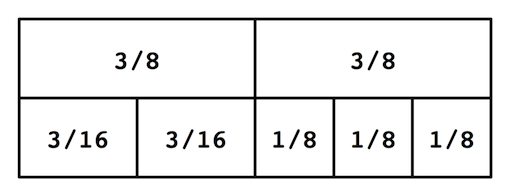

In [15]:
# 3/8 divisions
from IPython.display import Image #_DOCS_HIDE
Image(filename='images/usersGuide/advancedMeter-02.png') #_DOCS_HIDE

In [16]:
ms.depth

2

In [17]:
ms[0].depth

1

In [18]:
ms.flatten()

<music21.meter.core.MeterSequence {3/16+3/16+1/8+1/8+1/8}>

In [19]:
ms.getLevel(0)

<music21.meter.core.MeterSequence {3/8+3/8}>

In [20]:
ms.getLevel(1)

<music21.meter.core.MeterSequence {3/16+3/16+1/8+1/8+1/8}>

In [21]:
ms.getLevelSpan(1)

[(0.0, 0.75), (0.75, 1.5), (1.5, 2.0), (2.0, 2.5), (2.5, 3.0)]

In [22]:
ms[1].getLevelSpan(1)

[(0.0, 0.5), (0.5, 1.0), (1.0, 1.5)]

In [23]:
ms.offsetToIndex(2.5)

1

In [24]:
ms.offsetToSpan(2.5)

(1.5, 3.0)

In [25]:
ms.offsetToDepth(.5)

2

In [26]:
 ms[0].offsetToDepth(.5)

1

In [27]:
 ms.getLevel(1).offsetToSpan(.5)

(0, 0.75)

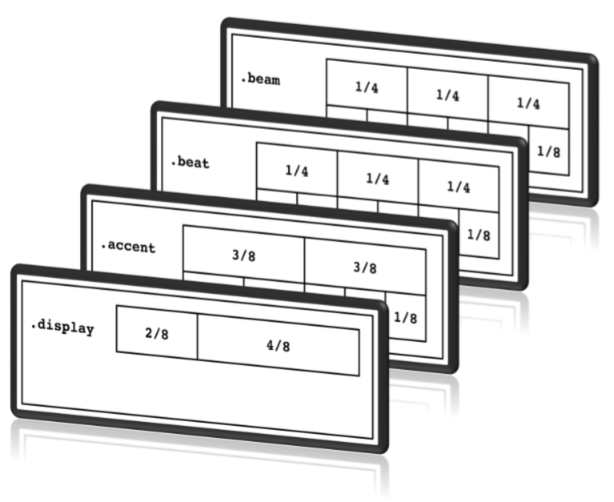

In [28]:
# four MeterSequence objects
Image(filename='images/usersGuide/overviewMeters-01.png', width=500) #_DOCS_HIDE

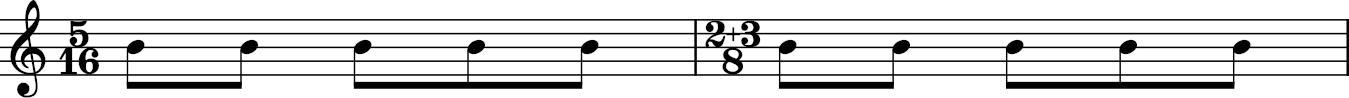

In [29]:
from music21 import stream, note
ts1 = meter.TimeSignature('5/8') # assumes two partitions
ts1.displaySequence.partition(['3/16', '1/8', '5/16'])
ts2 = meter.TimeSignature('5/8') # assumes two partitions
ts2.displaySequence.partition(['2/8', '3/8'])
ts2.summedNumerator = True
s = stream.Stream()
for ts in [ts1, ts2]:
    m = stream.Measure()
    m.timeSignature = ts
    n = note.Note('b')
    n.quarterLength = 0.5
    m.repeatAppend(n, 5)
    s.append(m)

s.show()


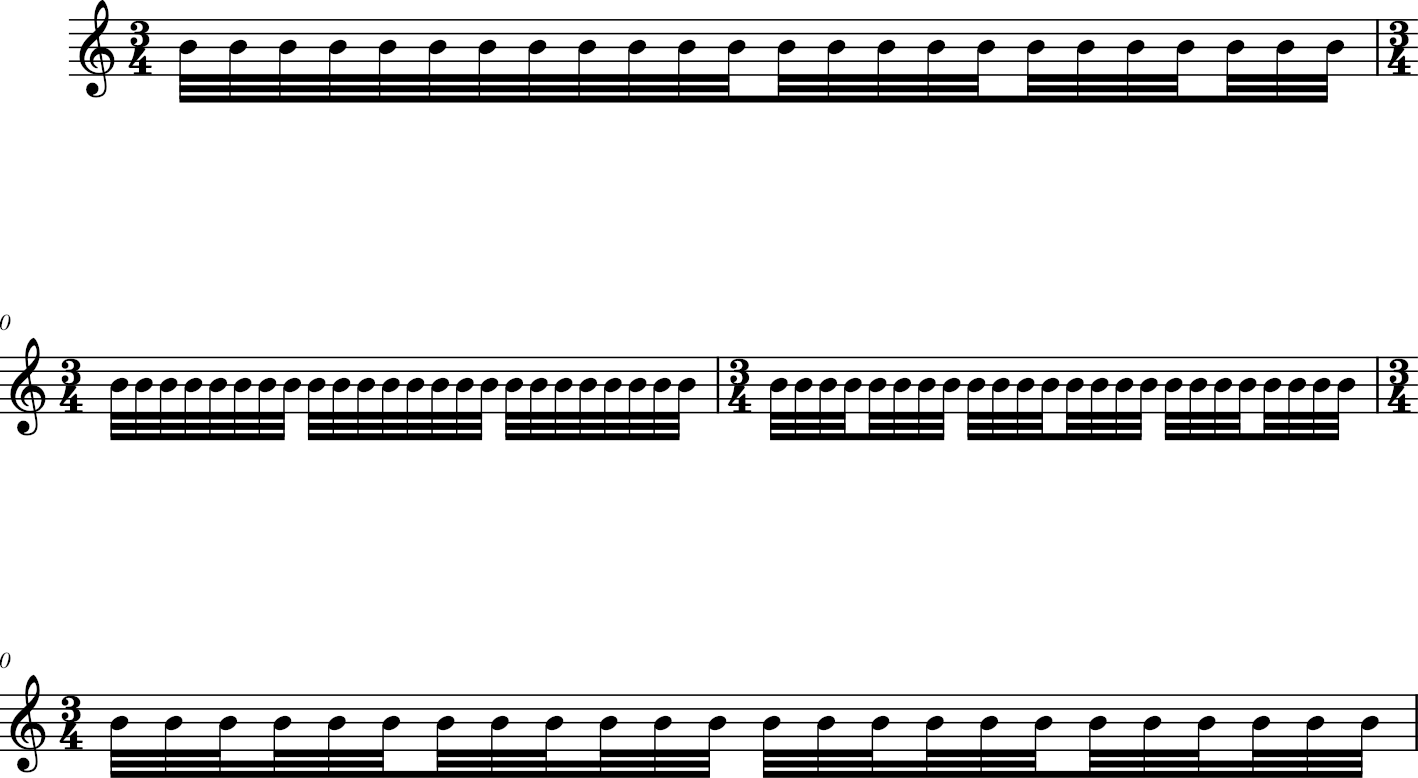

In [30]:
ts1 = meter.TimeSignature('3/4')
ts1.beamSequence.partition(1)
ts1.beamSequence[0] = ts1.beamSequence[0].subdivide(['3/8', '5/32', '4/32', '3/32'])

ts2 = meter.TimeSignature('3/4')
ts2.beamSequence.partition(3)

ts3 = meter.TimeSignature('3/4')
ts3.beamSequence.partition(3)

for i in range(len(ts3.beamSequence)):
    ts3.beamSequence[i] = ts3.beamSequence[i].subdivide(2)

ts4 = meter.TimeSignature('3/4')
ts4.beamSequence.partition(['3/8', '3/8'])
for i in range(len(ts4.beamSequence)):
    ts4.beamSequence[i] = ts4.beamSequence[i].subdivide(['6/32', '6/32'])
    for j in range(len(ts4.beamSequence[i])):
        ts4.beamSequence[i][j] = ts4.beamSequence[i][j].subdivide(2)

s = stream.Stream()
for ts in [ts1, ts2, ts3, ts4]:
    m = stream.Measure()
    m.timeSignature = ts
    n = note.Note('b')
    n.quarterLength = 0.125
    m.repeatAppend(n, 24)
    s.append(m.makeBeams())

s.show()

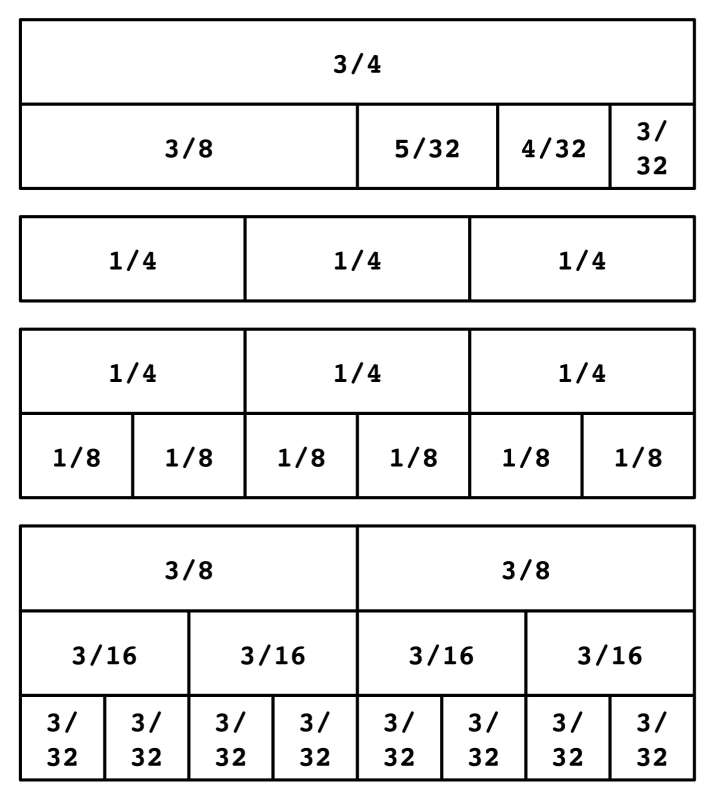

In [31]:
# four beam partitions
Image(filename='images/usersGuide/overviewMeters-03.jpg') #_DOCS_HIDE

In [32]:
ts = meter.TimeSignature('3/4')
ts.beatSequence.getLevel(0)

<music21.meter.core.MeterSequence {1/4+1/4+1/4}>

In [33]:
ts.beatSequence.getLevel(1)

<music21.meter.core.MeterSequence {1/8+1/8+1/8+1/8+1/8+1/8}>

In [34]:
ts.beatDuration

<music21.duration.Duration 1.0>

In [35]:
ts.beatCount

3

In [36]:
ts.beatCountName

'Triple'

In [37]:
ts.beatDivisionCount

2

In [38]:
ts.beatDivisionCountName

'Simple'

In [39]:
ts.classification

'Simple Triple'

In [40]:
ts = meter.TimeSignature('12/16')
ts.beatSequence.getLevel(0)

<music21.meter.core.MeterSequence {3/16+3/16+3/16+3/16}>

In [41]:
ts.beatSequence.getLevel(1)

<music21.meter.core.MeterSequence {1/16+1/16+1/16+1/16+1/16+1/16+1/16+1/16+1/16+1/16+1/16+1/16}>

In [42]:
ts.beatDuration

<music21.duration.Duration 0.75>

In [43]:
ts.beatCount

4

In [44]:
ts.beatCountName

'Quadruple'

In [45]:
ts.beatDivisionCount

3

In [46]:
ts.beatDivisionCountName

'Compound'

In [47]:
ts.classification

'Compound Quadruple'

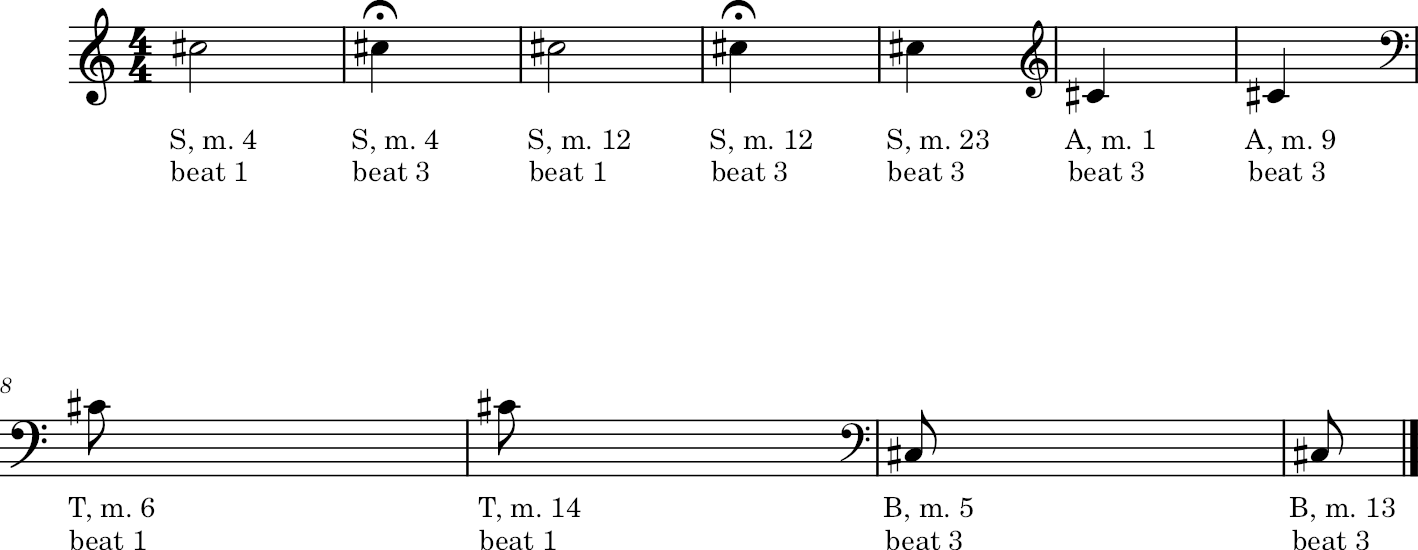

In [48]:
score = corpus.parse('bach/bwv366.xml')
ts = score[meter.TimeSignature].first()
ts.beatSequence.partition(3)

found = stream.Stream()
offsetQL = 0
for part in score.parts:
    found.insert(offsetQL, part[clef.Clef].first())
    for i in range(len(part.getElementsByClass(stream.Measure))):
        m = part[stream.Measure][i]
        for n in m.notesAndRests:
            if n.name == 'C#':
                n.addLyric(f'{part.id[0]}, m. {m.number}')
                n.addLyric(f'beat {ts.getBeat(n.offset)}')
                found.insert(offsetQL, n)
                offsetQL += 4

found.show()

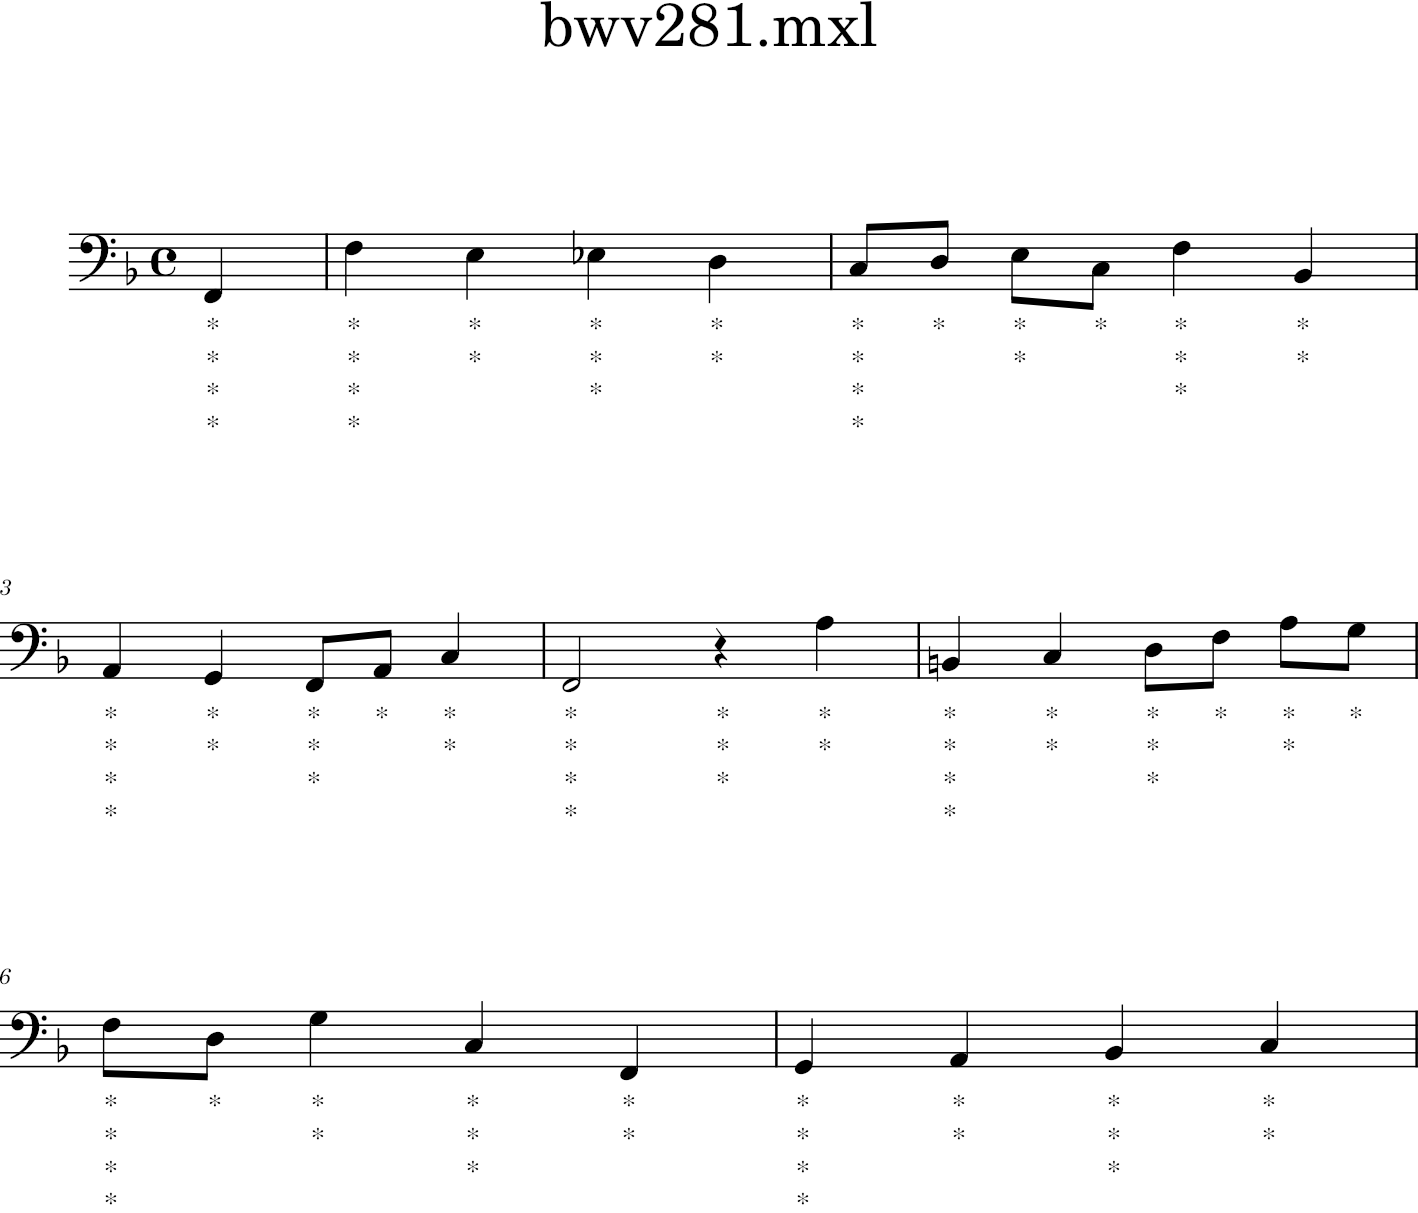

In [49]:
score = corpus.parse('bach/bwv281.xml')
partBass = score.getElementById('Bass')
ts = partBass[meter.TimeSignature].first()
ts.beatSequence.partition(1)
for h in range(len(ts.beatSequence)):
    ts.beatSequence[h] = ts.beatSequence[h].subdivide(2)
    for i in range(len(ts.beatSequence[h])):
        ts.beatSequence[h][i] = ts.beatSequence[h][i].subdivide(2)
        for j in range(len(ts.beatSequence[h][i])):
            ts.beatSequence[h][i][j] = ts.beatSequence[h][i][j].subdivide(2)

for m in partBass.getElementsByClass(stream.Measure):
    for n in m.notesAndRests:
        for i in range(ts.getBeatDepth(n.offset)):
            n.addLyric('*')

partBass.measures(0, 7).show()

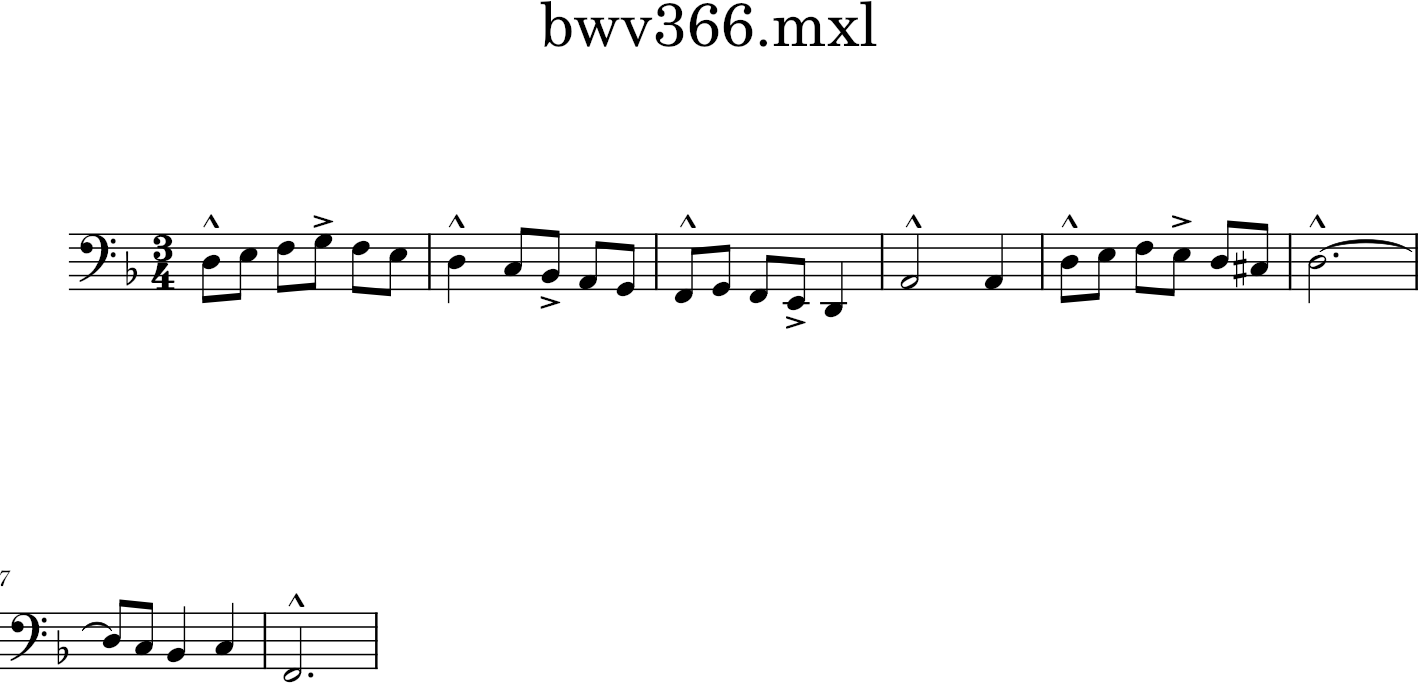

In [50]:
score = corpus.parse('bach/bwv366.xml')
partBass = score.getElementById('Bass')
ts = partBass[meter.TimeSignature].first()
ts.beatSequence.partition(['3/8', '3/8'])
ts.accentSequence.partition(['3/8', '3/8'])
ts.setAccentWeight([1, .5])
for m in partBass[stream.Measure]:
    lastBeat = None
    for n in m.notesAndRests:
        beat, progress = ts.getBeatProgress(n.offset)
        if beat != lastBeat and progress == 0:
            if n.tie != None and n.tie.type == 'stop':
                continue
            if ts.getAccentWeight(n.offset) == 1:
                mark = articulations.StrongAccent()
            elif ts.getAccentWeight(n.offset) == .5:
                mark = articulations.Accent()
            n.articulations.append(mark)
            lastBeat = beat
        m = m.sorted()

partBass.measures(0, 8).show()